# Aprendizaje supervisado: Random Forest

## Predicción de reincidencia

Un **Random Forest** reúne muchos árboles de decisión. Cada árbol vota y la clase con más votos se convierte en la predicción final. Al combinar árboles se reduce el riesgo de que un solo árbol se ajuste demasiado a los datos de entrenamiento.

> **Uso responsable:** este notebook es didáctico. Sus resultados no deben utilizarse como única base para decisiones judiciales o que afecten derechos.

## 1. Importar librerías

Usaremos `pandas` para las tablas, `scikit-learn` para el modelo y las métricas, y `matplotlib` para los gráficos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

## 2. Cargar y revisar los datos

Edita la ruta para indicar la ubicación de `base_seguridad_reincidencia.csv`. Revisamos la estructura y el equilibrio de la variable que se desea predecir.

In [2]:
RUTA_DATOS = r"datos\base_seguridad_reincidencia.csv"  # <-- edita esta ruta
datos = pd.read_csv(RUTA_DATOS)

display(datos.head())
datos.info()

print('Distribución de reincidencia:')
display(datos['reincidencia'].value_counts())
display(datos['reincidencia'].value_counts(normalize=True).mul(100).round(1))

,edad,delito_previo,num_delitos_previos,meses_en_prision,empleo,apoyo_familiar,consumo_sustancias,nivel_educativo,supervision_post,reincidencia
0,56,Robo,1,28,No,Si,No,Universidad,Media,No
1,46,Violencia_familiar,2,25,Si,No,No,Secundaria,Baja,Si
2,32,Robo,0,45,No,Si,No,Preparatoria,Baja,No
3,60,Narcomenudeo,2,15,Si,No,No,Preparatoria,Baja,No
4,25,Violencia_familiar,1,30,No,Si,Si,Secundaria,Media,Si


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   edad                 1000 non-null   int64
 1   delito_previo        1000 non-null   str  
 2   num_delitos_previos  1000 non-null   int64
 3   meses_en_prision     1000 non-null   int64
 4   empleo               1000 non-null   str  
 5   apoyo_familiar       1000 non-null   str  
 6   consumo_sustancias   1000 non-null   str  
 7   nivel_educativo      1000 non-null   str  
 8   supervision_post     1000 non-null   str  
 9   reincidencia         1000 non-null   str  
dtypes: int64(3), str(7)
memory usage: 109.6 KB
Distribución de reincidencia:


reincidencia
No    620
Si    380
Name: count, dtype: int64

reincidencia
No    62.0
Si    38.0
Name: proportion, dtype: float64

## 3. Preparar variables predictoras y objetivo

`y` contiene la respuesta que se quiere aprender (`reincidencia`). `X` contiene las características de cada persona. Las variables de texto se convierten en columnas binarias mediante *one-hot encoding* (`get_dummies`).

In [3]:
le_objetivo = LabelEncoder()
y = le_objetivo.fit_transform(datos['reincidencia'])

X = datos.drop(columns='reincidencia')
columnas_categoricas = [
    'delito_previo', 'empleo', 'apoyo_familiar',
    'consumo_sustancias', 'nivel_educativo', 'supervision_post'
]
X = pd.get_dummies(X, columns=columnas_categoricas, dtype=int)

print('Codificación de la clase:', dict(enumerate(le_objetivo.classes_)))
print('Variables predictoras:', X.shape[1])
display(X.head())

Codificación de la clase: {0: 'No', 1: 'Si'}
Variables predictoras: 20


,edad,num_delitos_previos,meses_en_prision,delito_previo_Fraude,delito_previo_Narcomenudeo,delito_previo_Robo,delito_previo_Violencia_familiar,empleo_No,empleo_Si,apoyo_familiar_No,apoyo_familiar_Si,consumo_sustancias_No,consumo_sustancias_Si,nivel_educativo_Preparatoria,nivel_educativo_Primaria,nivel_educativo_Secundaria,nivel_educativo_Universidad,supervision_post_Alta,supervision_post_Baja,supervision_post_Media
0,56,1,28,0,0,1,0,1,0,0,1,1,0,0,0,0,1,0,0,1
1,46,2,25,0,0,0,1,0,1,1,0,1,0,0,0,1,0,0,1,0
2,32,0,45,0,0,1,0,1,0,0,1,1,0,1,0,0,0,0,1,0
3,60,2,15,0,1,0,0,0,1,1,0,1,0,1,0,0,0,0,1,0
4,25,1,30,0,0,0,1,1,0,0,1,0,1,0,0,1,0,0,0,1


## 4. Separar entrenamiento y prueba

El modelo se entrena con el 80 % de los casos y se evalúa con el 20 % restante. `stratify=y` conserva la proporción de clases en las dos particiones.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=3, stratify=y
)
print(f'Entrenamiento: {X_train.shape[0]} personas')
print(f'Prueba:        {X_test.shape[0]} personas')

Entrenamiento: 800 personas
Prueba:        200 personas


## 5. Crear y entrenar el Random Forest

- `n_estimators=500`: número de árboles que forman el bosque.
- `max_depth=6` y `min_samples_leaf=10`: limitan la complejidad de cada árbol.
- `class_weight='balanced'`: compensa la menor frecuencia de una clase.
- `n_jobs=-1`: permite usar los núcleos disponibles del procesador.

In [5]:
modelo_rf = RandomForestClassifier(
    n_estimators=500, max_depth=6, min_samples_leaf=10,
    class_weight='balanced', random_state=3, n_jobs=-1
)
modelo_rf.fit(X_train, y_train)
print(f'Random Forest entrenado con {modelo_rf.n_estimators} árboles.')

Random Forest entrenado con 500 árboles.


## 6. Importancia de las variables

Esta importancia es el promedio de las contribuciones de cada variable a través de los árboles. Sirve para interpretar el modelo, pero no demuestra causalidad.

,importancia
empleo_No,0.183743
empleo_Si,0.165868
consumo_sustancias_No,0.109167
num_delitos_previos,0.107596
consumo_sustancias_Si,0.106109
apoyo_familiar_Si,0.081063
apoyo_familiar_No,0.071123
edad,0.046609
supervision_post_Alta,0.027675
meses_en_prision,0.023383


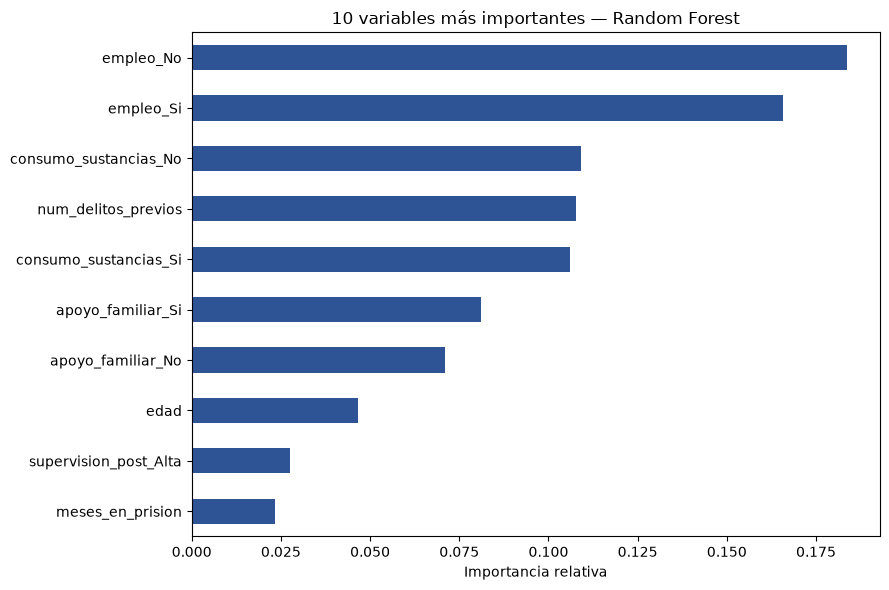

In [6]:
importancias_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
display(importancias_rf.head(10).to_frame('importancia'))

fig, ax = plt.subplots(figsize=(9, 6))
importancias_rf.head(10).sort_values().plot.barh(ax=ax, color='#2F5496')
ax.set_xlabel('Importancia relativa')
ax.set_title('10 variables más importantes — Random Forest')
plt.tight_layout()
plt.show()

## 7. Predicciones y evaluación

Además de la etiqueta predicha, se calcula la probabilidad de reincidencia. La matriz de confusión muestra aciertos y errores por clase; el reporte incluye *precision*, *recall* y F1.

Exactitud general: 0.870

              precision    recall  f1-score   support

          No       0.92      0.87      0.89       124
          Si       0.80      0.87      0.84        76

    accuracy                           0.87       200
   macro avg       0.86      0.87      0.86       200
weighted avg       0.87      0.87      0.87       200



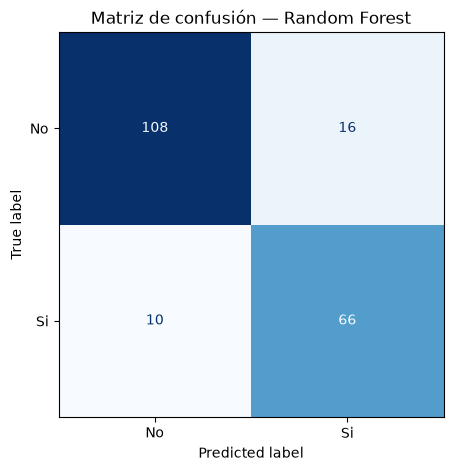

In [7]:
pred_rf = modelo_rf.predict(X_test)
proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

print(f'Exactitud general: {accuracy_score(y_test, pred_rf):.3f}\n')
print(classification_report(y_test, pred_rf, target_names=le_objetivo.classes_))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_rf, display_labels=le_objetivo.classes_,
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('Matriz de confusión — Random Forest')
plt.show()

## 8. Curva de aprendizaje: ¿cuántos árboles se necesitan?

Entrenamos varios bosques con distinto número de árboles. La línea de prueba es la más importante: representa el rendimiento sobre personas que el modelo no vio durante el entrenamiento. Si se estabiliza, añadir más árboles ofrece poca mejora.

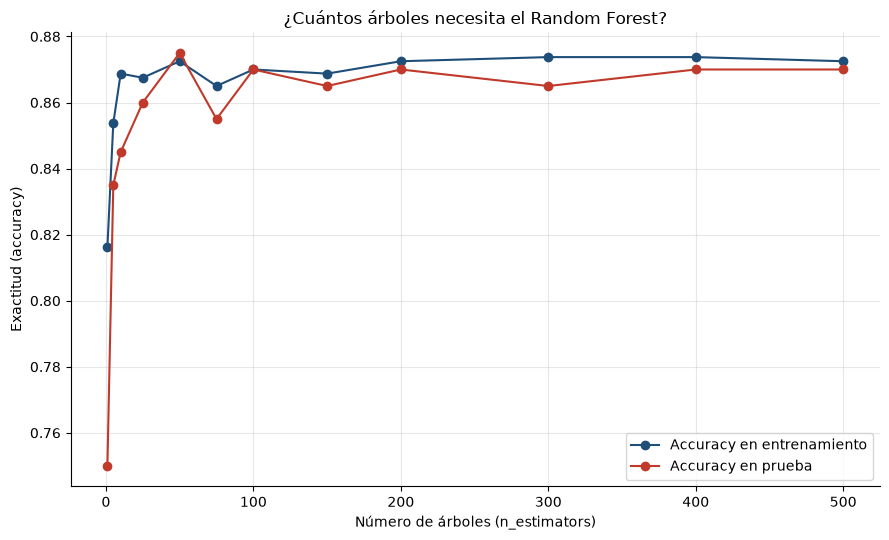

In [8]:
n_arboles_lista = [1, 5, 10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
acc_train, acc_test = [], []

for n in n_arboles_lista:
    rf_temp = RandomForestClassifier(
        n_estimators=n, max_depth=6, min_samples_leaf=10,
        class_weight='balanced', random_state=3, n_jobs=-1
    )
    rf_temp.fit(X_train, y_train)
    acc_train.append(accuracy_score(y_train, rf_temp.predict(X_train)))
    acc_test.append(accuracy_score(y_test, rf_temp.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(n_arboles_lista, acc_train, marker='o', color='#1F4E79', label='Accuracy en entrenamiento')
ax.plot(n_arboles_lista, acc_test, marker='o', color='#C0392B', label='Accuracy en prueba')
ax.set_xlabel('Número de árboles (n_estimators)')
ax.set_ylabel('Exactitud (accuracy)')
ax.set_title('¿Cuántos árboles necesita el Random Forest?')
ax.legend()
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Aplicar el modelo a registros nuevos

En uso real, los registros nuevos no incluyen `reincidencia`; esa es la incógnita. Es imprescindible codificarlos igual que los datos de entrenamiento y reordenar sus columnas con `reindex(columns=X.columns)`. Así se evita que el modelo reciba columnas faltantes, adicionales o en un orden incorrecto.

In [9]:
RUTA_NUEVOS = r"datos\nuevos_registros_reincidencia.csv"  # <-- edita esta ruta
nuevos = pd.read_csv(RUTA_NUEVOS)

nuevos_dummies = pd.get_dummies(
    nuevos, columns=columnas_categoricas, dtype=int
)
nuevos_dummies = nuevos_dummies.reindex(columns=X.columns, fill_value=0)

predicciones_nuevas = modelo_rf.predict(nuevos_dummies)
probabilidades_nuevas = modelo_rf.predict_proba(nuevos_dummies)[:, 1]

resultados = nuevos.copy()
resultados['prediccion_reincidencia'] = le_objetivo.inverse_transform(predicciones_nuevas)
resultados['probabilidad_reincidencia'] = probabilidades_nuevas.round(3)
resultados = resultados.sort_values('probabilidad_reincidencia', ascending=False)

columnas_mostrar = [
    'edad', 'delito_previo', 'empleo', 'consumo_sustancias',
    'num_delitos_previos', 'prediccion_reincidencia', 'probabilidad_reincidencia'
]
display(resultados[columnas_mostrar])

,edad,delito_previo,empleo,consumo_sustancias,num_delitos_previos,prediccion_reincidencia,probabilidad_reincidencia
3,27,Robo,No,No,2,Si,0.774
0,19,Robo,Si,Si,2,Si,0.618
1,53,Robo,No,No,1,No,0.494
2,58,Fraude,Si,Si,1,No,0.449
5,36,Violencia_familiar,No,No,1,No,0.379
7,23,Narcomenudeo,Si,Si,0,No,0.368
8,19,Fraude,No,No,1,No,0.360
6,22,Robo,No,No,0,No,0.265
4,58,Violencia_familiar,Si,No,1,No,0.059
9,41,Robo,Si,No,1,No,0.041


## Conclusión

El Random Forest permite obtener predicciones más estables que un árbol único, además de probabilidades para priorizar el análisis de casos. Antes de usar el modelo, compara métricas por clase y revisa sesgos, calidad de datos y consecuencias de cada tipo de error.